In [1]:
import shap
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt
shap.initjs()

# Load best model from MLflow registry
model = mlflow.sklearn.load_model('models:/credit-risk-lgbm/1')

# Load test data (apply same preprocessing)
import sys; sys.path.append('..')
from src.features.feature_engineering import CreditRiskFeatures
df    = pd.read_csv('../data/raw/application_train.csv')
fe    = CreditRiskFeatures()
X     = df.drop(columns=['TARGET','SK_ID_CURR'])
X_tr  = fe.fit_transform(X)

# Sample for speed
X_sample = X_tr.sample(2000, random_state=42)

# SHAP values
lgbm_model = model.named_steps['model']
explainer   = shap.TreeExplainer(lgbm_model)
shap_vals   = explainer.shap_values(X_sample)


c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'src'

In [2]:
import mlflow

mlflow.set_tracking_uri('http://localhost:5000')
client = mlflow.tracking.MlflowClient()

# Get all experiments
experiments = client.search_experiments()
for exp in experiments:
    print(f"Experiment: {exp.name} | ID: {exp.experiment_id}")

# Get latest run and list its artifacts
runs = client.search_runs(
    experiment_ids=[exp.experiment_id for exp in experiments],
    order_by=['start_time DESC'],
    max_results=5
)

for run in runs:
    print(f"\nRun ID: {run.info.run_id}")
    print(f"Run Name: {run.info.run_name}")
    print(f"Status: {run.info.status}")
    
    # List artifacts in this run
    artifacts = client.list_artifacts(run.info.run_id)
    print("Artifacts:")
    for art in artifacts:
        print(f"  - {art.path}  (is_dir: {art.is_dir})")

Experiment: credit-risk-default-prediction | ID: 762678641237740655
Experiment: Default | ID: 0

Run ID: 5ae51c29ee554855b71f34616b3169d8
Run Name: lgbm-baseline-v1
Status: FINISHED
Artifacts:


In [3]:
import mlflow
import os

# Point to your project root explicitly
PROJECT_ROOT = r"c:/Users/Shanu/Desktop/Final_projects/fraud_detection/credit-risk-platform"
MLRUNS_PATH  = os.path.join(PROJECT_ROOT, "mlruns")

mlflow.set_tracking_uri(f"http://127.0.0.1:5000")
mlflow.set_experiment("credit-risk-default-prediction")

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLruns path:  {MLRUNS_PATH}")

Tracking URI: http://127.0.0.1:5000
MLruns path:  c:/Users/Shanu/Desktop/Final_projects/fraud_detection/credit-risk-platform\mlruns


In [4]:
import sys
import os

# Add project root to path so Python can find your src/ folder
PROJECT_ROOT = r"c:/Users/Shanu/Desktop/Final_projects/fraud_detection/credit-risk-platform"
sys.path.insert(0, PROJECT_ROOT)

# Now import your custom class
from src.features.credit_risk_features import CreditRiskFeatures

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")
print(f"Project root: {PROJECT_ROOT}")

All imports successful!
Project root: c:/Users/Shanu/Desktop/Final_projects/fraud_detection/credit-risk-platform


In [ ]:
# Load model
mlflow.set_tracking_uri("http://127.0.0.1:5000")
RUN_ID = "5ae51c29ee554855b71f34616b3169d8"  # your run ID
model  = mlflow.sklearn.load_model(f"runs:/{RUN_ID}/credit-risk-pipeline")

# Load data
df     = pd.read_csv(os.path.join(PROJECT_ROOT, "data/raw/home_credit/application_train.csv"))
X      = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y      = df['TARGET']

# Apply feature engineering
fe       = CreditRiskFeatures()
X_fe     = fe.fit_transform(X)
X_sample = X_fe.sample(2000, random_state=42)

print(f"Data shape:  {X_fe.shape}")
print(f"Sample size: {X_sample.shape}")
print("Ready for SHAP!")

In [22]:
import os
import sys

project_root = r"C:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform"

print("1️⃣ Project root exists:", os.path.exists(project_root))

print("\n2️⃣ Contents of project root:")
print(os.listdir(project_root))

print("\n3️⃣ Does src exist?")
print(os.path.exists(os.path.join(project_root, "src")))

print("\n4️⃣ Contents of src:")
print(os.listdir(os.path.join(project_root, "src")))

print("\n5️⃣ Contents of src/features:")
print(os.listdir(os.path.join(project_root, "src", "features")))

# Add to path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("\n6️⃣ sys.path contains project root?")
print(project_root in sys.path)

# Try import
try:
    import src
    print("\n7️⃣ import src works ✅")
except Exception as e:
    print("\n7️⃣ import src FAILED:", e)

try:
    import src.features
    print("8️⃣ import src.features works ✅")
except Exception as e:
    print("8️⃣ import src.features FAILED:", e)

1️⃣ Project root exists: True

2️⃣ Contents of project root:
['.env', '.git', '.github', '.gitignore', 'app', 'credit_risk_dbt', 'dags', 'data', 'dbt', 'dbt_project.yml', 'docker-compose.yml', 'infrastructure', 'logs', 'mlartifacts', 'mlflow.db', 'mlruns', 'notebooks', 'reports', 'requirements.txt', 'sql', 'src', 'target', 'tests', 'venv']

3️⃣ Does src exist?
True

4️⃣ Contents of src:
['data', 'features', 'models', 'monitoring', 'reports', '__init__.py']

5️⃣ Contents of src/features:
['credit_risk_features.py', '__init__.py', '__pycache__']

6️⃣ sys.path contains project root?
True

7️⃣ import src works ✅
8️⃣ import src.features FAILED: No module named 'src.features'


In [24]:
import sys
import os
import pandas as pd
import mlflow
import shap
import matplotlib.pyplot as plt

# Set project root
project_root = r"C:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")

# Load model from MLflow
model = mlflow.sklearn.load_model("models:/credit-risk-lgbm/1")
print("✅ Model loaded successfully")

# Correct import based on actual file
from src.features.credit_risk_features import CreditRiskFeatures

# Load and preprocess data
df = pd.read_csv(os.path.join(project_root, "data/raw/application_train.csv"))
fe = CreditRiskFeatures()

X = df.drop(columns=['TARGET','SK_ID_CURR'])
X_tr = fe.fit_transform(X)

# Sample for SHAP
X_sample = X_tr.sample(2000, random_state=42)

# SHAP
explainer = shap.Explainer(model, X_sample)
shap_vals = explainer(X_sample)

# Global summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals.values,  # matrix, not vector
    X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Top 20 Features Driving Default Predictions', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'reports/shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'src.features'

In [20]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")

model = mlflow.sklearn.load_model("models:/credit-risk-lgbm/1")

print("Model loaded successfully ✅")

ModuleNotFoundError: No module named 'src.features'

In [19]:
from src.features.feature_engineering import CreditRiskFeatures

fe = CreditRiskFeatures()

In [20]:
df = pd.read_csv('../data/raw/application_train.csv')

X = df.drop(columns=['TARGET','SK_ID_CURR'])

X_tr = fe.fit_transform(X)

X_sample = X_tr.sample(2000, random_state=42)

X_transformed shape: (2000, 131)


c:\Users\Shanu\Desktop\Final_projects\fraud_detection\credit-risk-platform\venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP shape: (2000, 131)


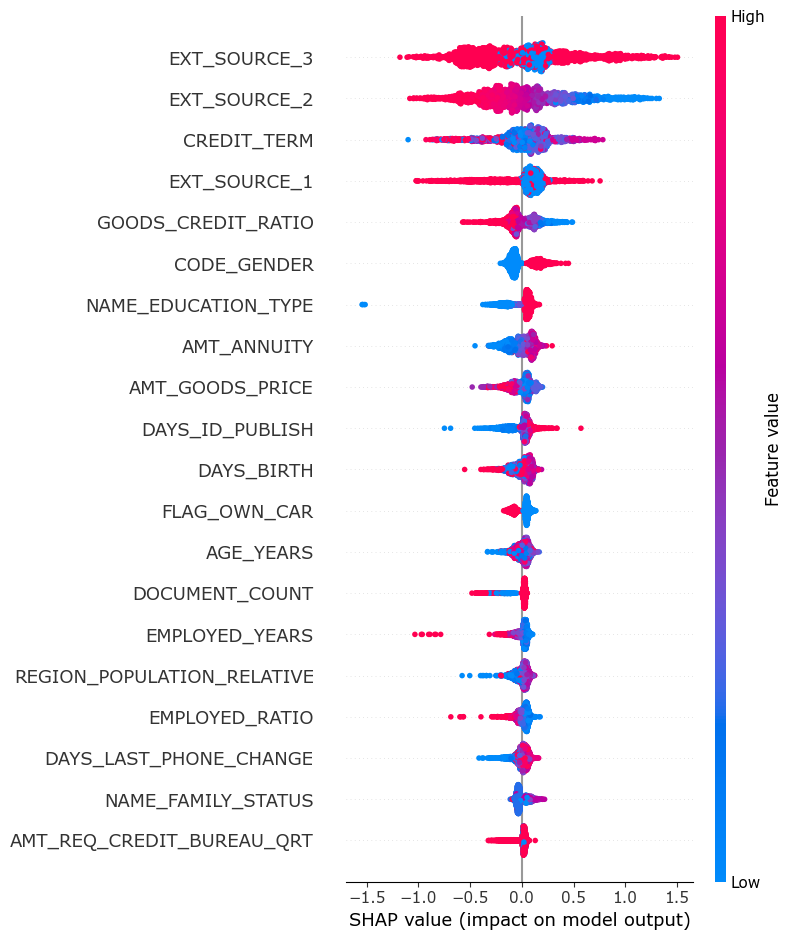

In [35]:
# 1️⃣ Transform using your feature step
X_transformed = model.named_steps["features"].transform(X_sample)

print("X_transformed shape:", X_transformed.shape)

# 2️⃣ Extract LightGBM
lgbm_model = model.named_steps["model"]

# 3️⃣ SHAP
import shap

explainer = shap.TreeExplainer(lgbm_model)
shap_vals = explainer.shap_values(X_transformed)

print("SHAP shape:", shap_vals.shape)

shap.summary_plot(shap_vals, X_transformed)

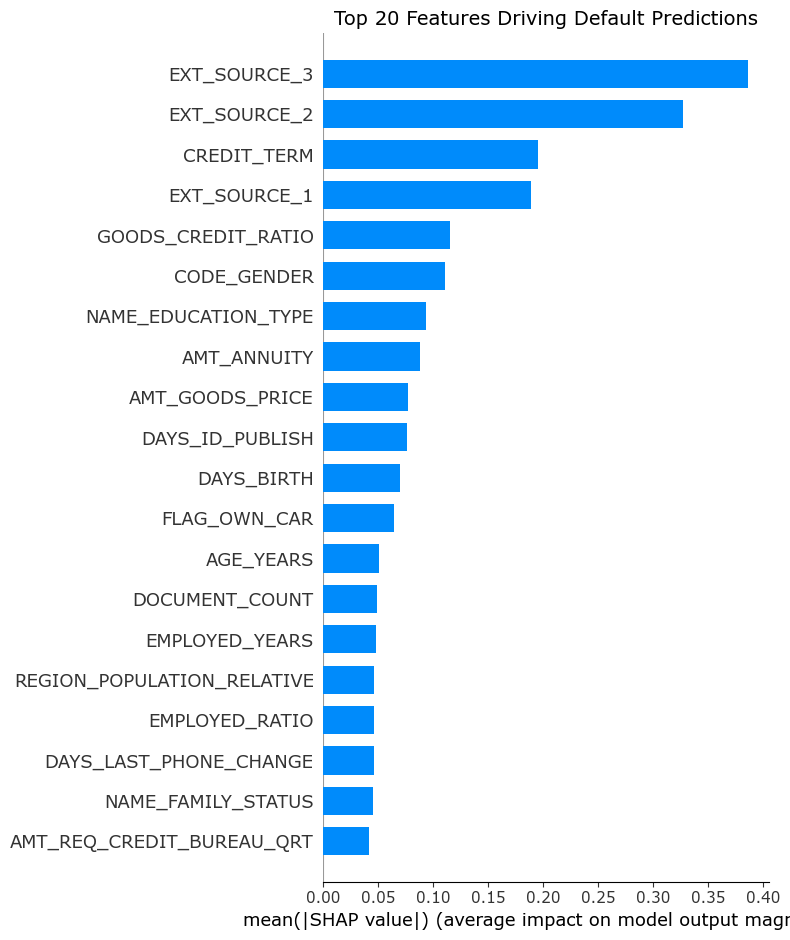

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_vals,            # ✅ NO [1]
    X_transformed,        # must match shap_vals
    plot_type='bar',
    max_display=20,
    show=False
)

plt.title('Top 20 Features Driving Default Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
def explain_decision(customer_idx):

    # Prediction
    prob = model.predict_proba(X.iloc[[customer_idx]])[:, 1][0]
    decision = 'DECLINE' if prob > 0.30 else 'APPROVE'

    print(f'Customer #{customer_idx}')
    print(f'Default Probability: {prob:.1%}')
    print(f'Decision: {decision}')
    print('-' * 40)

    # Transform features
    X_fe = model.named_steps["features"].transform(X.iloc[[customer_idx]])

    # Convert to DataFrame if numpy
    if not hasattr(X_fe, "iloc"):
        X_fe = pd.DataFrame(X_fe)

    # SHAP explanation (modern way)
    explanation = explainer(X_fe)

    shap.waterfall_plot(explanation[0])
    plt.show()